# Kiểm tra Google Colab + Dependencies

In [ ]:
!nvidia-smi

Tue Aug 18 14:22:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("CUDA runtime:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)

    print(f"\nGPU {i}")
    print("Name:", torch.cuda.get_device_name(i))
    print(f"VRAM: {props.total_memory / 1024**3:.2f} GB")
    print("Compute capability:", f"{props.major}.{props.minor}")

PyTorch: 2.11.0+cu128
TorchVision: 0.26.0+cu128
CUDA runtime: 12.8
CUDA available: True
GPU count: 1

GPU 0
Name: Tesla T4
VRAM: 14.56 GB
Compute capability: 7.5


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


In [ ]:
!git clone https://github.com/khoaleduong/hardhat-detection.git
%cd hardhat-detection

Cloning into 'hardhat-detection'...
remote: Enumerating objects: 78, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 78 (delta 23), reused 68 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (78/78), 2.22 MiB | 5.66 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/hardhat-detection


In [ ]:
import torch
import torchvision

print("Torch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("CUDA runtime:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128
TorchVision: 0.26.0+cu128
CUDA runtime: 12.8
CUDA available: True
GPU: Tesla T4


In [ ]:
!pip install -q uv
!uv pip install --system -r pyproject.toml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 37.3 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 82 packages in 687ms
Prepared 14 packages in 584ms
Uninstalled 7 packages in 51ms
Installed 14 packages in 30ms
 - albucore==0.0.24
 + albucore==0.0.20
 - albumentations==2.0.8
 + albumentations==1.4.21
 + eval-type-backport==0.4.0
 + filetype==1.2.0
 + lightning-utilities==0.15.3
 - matplotlib==3.10.0
 + matplotlib==3.11.1
 + pi-heif==1.4.0
 + pillow-avif-plugin==1.6.0
 - protobuf==5.29.6
 + protobuf==7.35.1
 - python-dotenv==1.2.2
 + python-dotenv==1.2.3
 + roboflow==1.4.1
 - tensorboard==2.20.0
 + tensorboard==2.21.0
 + torchmetrics==1.9.0
 - typer==0.26.8
 + typer==0.25.1


In [ ]:
import torch
import torchvision
import numpy as np
import cv2
import albumentations as A
import torchmetrics

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("numpy:", np.__version__)
print("opencv:", cv2.__version__)
print("albumentations:", A.__version__)
print("torchmetrics:", torchmetrics.__version__)

/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


torch: 2.11.0+cu128
torchvision: 0.26.0+cu128
CUDA: 12.8
CUDA available: True
numpy: 2.0.2
opencv: 5.0.0
albumentations: 1.4.21
torchmetrics: 1.9.0


In [ ]:
assert torch.cuda.is_available(), "CUDA is not available"

x = torch.randn(1000, 1000, device="cuda")
y = x @ x

print("Device:", y.device)
print("GPU test: OK")

Device: cuda:0
GPU test: OK


# Download dataset from Roboflow

In [ ]:
from google.colab import userdata
import os

os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

In [ ]:
api_key = os.getenv("ROBOFLOW_API_KEY")

assert api_key, "ROBOFLOW_API_KEY is missing"
print("Roboflow API key: configured ✓")

Roboflow API key: configured ✓


In [ ]:
!python scripts/download_data.py

Project root: /content/hardhat-detection
Download to : /content/hardhat-detection/data
loading Roboflow workspace...
loading Roboflow project...

Extracting Dataset Version Zip to /content/hardhat-detection/data in yolov8:: 100% 21895/21895 [00:03<00:00, 6573.00it/s] 

Download completed.
Dataset location: /content/hardhat-detection/data


# Test

In [ ]:
%cd data
!cp -r test valid

/content/hardhat-detection/data


In [ ]:
!pwd
%cd ..

/content/hardhat-detection/data
/content/hardhat-detection


In [ ]:
!pytest tests/test_dataset.py -v
!pytest tests/test_dataloader.py -v
!pytest tests/test_model.py -v

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/hardhat-detection
configfile: pyproject.toml
plugins: langsmith-0.10.2, anyio-4.14.2, typeguard-4.5.2
collected 5 items                                                              

tests/test_dataset.py::test_normal_sample PASSED                         [ 20%]
tests/test_dataset.py::test_yolo_box_conversion PASSED                   [ 40%]
tests/test_dataset.py::test_empty_annotation PASSED                      [ 60%]
tests/test_dataset.py::test_invalid_non_integer_class PASSED             [ 80%]
tests/test_dataset.py::test_out_of_range_class PASSED                    [100%]

=============================== warnings summary ===============================
../../usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:24
  /usr/local/lib/python3.12/dist-packages/albumentations

In [ ]:
!python train_smoke.py

/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
2026-08-18 14:25:17.710656: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:243: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
SMOKE TRAIN
Device: cuda
Train samples: 64
Valid samples: 16
Batch size: 1
Epochs: 2
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cac

# Train

In [ ]:
from google.colab import drive
from pathlib import Path
import os

drive.mount("/content/drive")

CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/hardhat-detection/checkpoints"
)

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

os.environ["CHECKPOINT_DIR"] = str(CHECKPOINT_DIR)

print("CHECKPOINT_DIR =", CHECKPOINT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CHECKPOINT_DIR = /content/drive/MyDrive/hardhat-detection/checkpoints


In [ ]:
test_file = CHECKPOINT_DIR / "_write_test.txt"

test_file.write_text("ok")
assert test_file.exists()

test_file.unlink()

print("Google Drive write test: OK")

Google Drive write test: OK


In [ ]:
# %cd /content/hardhat-detection
# !git pull origin main
# from config import BATCH_SIZE, NUM_EPOCHS
# print(BATCH_SIZE, NUM_EPOCHS)

/content/hardhat-detection
BATCH_SIZE = 16


In [ ]:
%cd /content/hardhat-detection
!python train.py

/content/hardhat-detection
2026-08-18 14:45:42.549252: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
Using device: cuda
/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:243: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
Train samples: 9177
Valid samples: 1766
Start Training from Epoch 1 to 10
Epoch 001 [Train]: 100% 574/574 [13:52<00:00,  1.45s/it, loss=0.3222, l

# Evaluate

In [ ]:
%cd /content/hardhat-detection
!git pull origin main

/content/hardhat-detection
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 9 (delta 6), reused 9 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 2.68 KiB | 1.34 MiB/s, done.
From https://github.com/khoaleduong/hardhat-detection
 * branch            main       -> FETCH_HEAD
   da434d7..453ca3e  main       -> origin/main
Updating da434d7..453ca3e
Fast-forward
 evaluate.py               |  17 ++++---
 predict.py                | 117 ++++++++++++++++++++++++++++++++++++++++++++++
 src/dataset/dataloader.py |  23 +++++++++
 tests/test_dataloader.py  |  37 ++++++++++++++-
 4 files changed, 183 insertions(+), 11 deletions(-)


In [ ]:
%cd /content/hardhat-detection

/content/hardhat-detection


In [ ]:
from pathlib import Path
import os

best_model = Path(os.environ["CHECKPOINT_DIR"]) / "best_model.pth"

print("Checkpoint:", best_model)
print("Exists:", best_model.exists())

Checkpoint: /content/drive/MyDrive/hardhat-detection/checkpoints/best_model.pth
Exists: True


In [ ]:
!python evaluate.py

/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
Evaluating best checkpoint
Device: cuda
Checkpoint: /content/drive/MyDrive/hardhat-detection/checkpoints/best_model.pth
/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:243: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
Validation samples: 1766
Loaded checkpoint: /content/drive/MyDrive/hardhat-detection/checkpoints/best_model.pth (epoch 5)
Evaluation: 100% 111/111 [01:33<00:00,  1.19it/s]
Evaluation Results
mAP@50:95           : 0.4340
mAP@50              : 0.6555
mAP@75              : 0.5130
mAR@1               : 0.1996
mAR@10              : 0.6434
mAR@100             : 0.6596

AP Per Class
------------

In [ ]:
!python predict.py "/content/hardhat-detection/data/test/images/005311_jpg.rf.3908384b6ccdf9936958cb537f9685e1.jpg" \
    --score-threshold 0.5 \
    --output "/content/prediction.jpg"

Loaded checkpoint: /content/drive/MyDrive/hardhat-detection/checkpoints/best_model.pth (epoch 5)
Image: /content/hardhat-detection/data/test/images/005311_jpg.rf.3908384b6ccdf9936958cb537f9685e1.jpg
Device: cuda
Threshold: 0.5
Detections kept: 3
helmet   score=1.00 box=[209.3, 207.5, 290.3, 354.2]
helmet   score=1.00 box=[306.9, 165.0, 396.6, 339.1]
helmet   score=1.00 box=[123.1, 150.2, 219.2, 342.0]
Output: /content/prediction.jpg


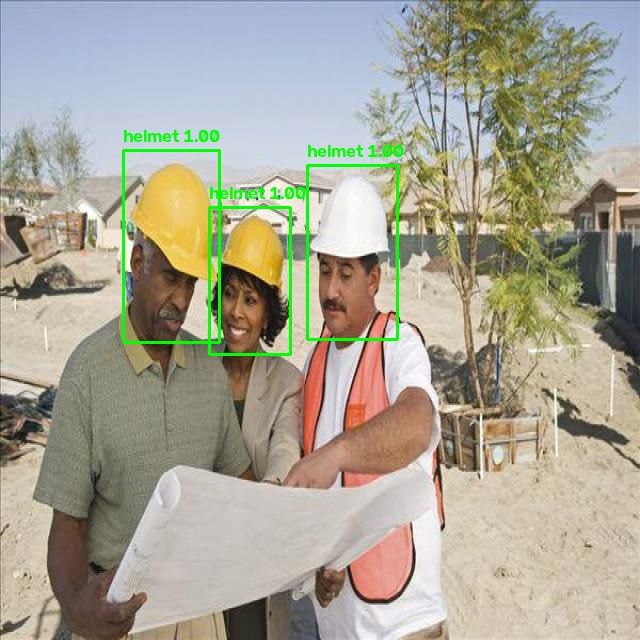

In [ ]:
from IPython.display import Image, display

display(Image("/content/prediction.jpg"))

# Test random online images

In [ ]:
import requests

url = "https://www.hbnext.com/wp-content/uploads/2026/02/bottom-view-of-group-of-builders-in-hard-hats-and.jpg"

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 Chrome/140.0.0.0 Safari/537.36"
    ),
    "Referer": "https://www.hbnext.com/",
}

response = requests.get(
    url,
    headers=headers,
    timeout=30,
)

response.raise_for_status()

with open("/content/test_external.jpg", "wb") as f:
    f.write(response.content)

print("Downloaded:", len(response.content), "bytes")

Downloaded: 261499 bytes


In [ ]:
!python predict.py "/content/test_external.jpg" \
    --score-threshold 0.5 \
    --output "/content/prediction_external.jpg"

Loaded checkpoint: /content/drive/MyDrive/hardhat-detection/checkpoints/best_model.pth (epoch 5)
Image: /content/test_external.jpg
Device: cuda
Threshold: 0.5
Detections kept: 3
helmet   score=1.00 box=[520.2, 3.9, 800.0, 314.5]
helmet   score=1.00 box=[251.6, 105.0, 470.3, 372.3]
helmet   score=1.00 box=[47.8, 172.2, 230.3, 402.2]
Output: /content/prediction_external.jpg


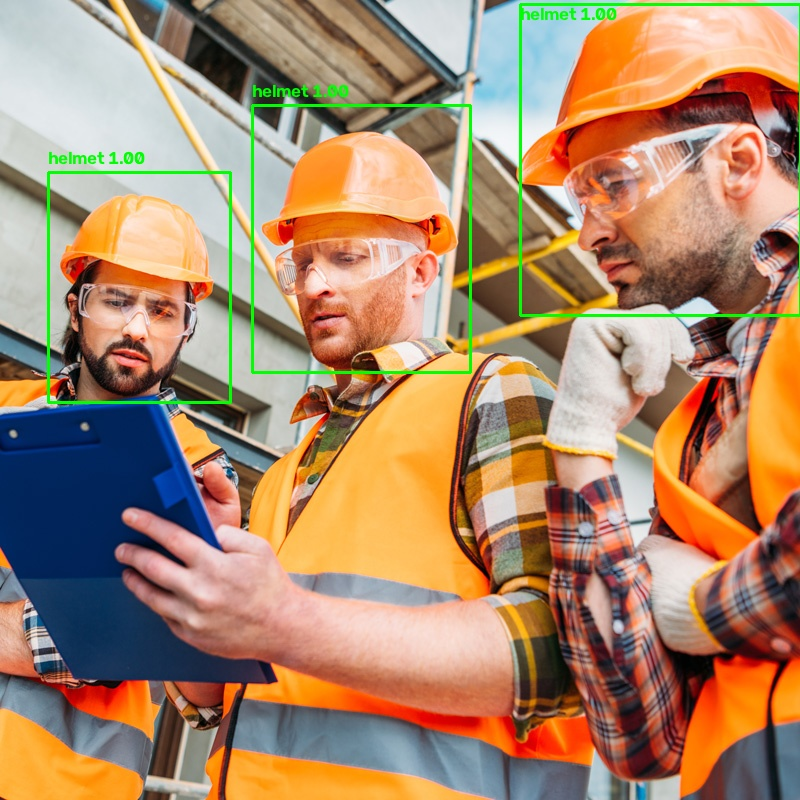

In [ ]:
from IPython.display import Image, display

display(Image("/content/prediction_external.jpg"))